# Falsos positivos y negativos en el cumplimiento normativo (NCh433)
### El metamodelo PINN como herramienta de tamizado de cumplimiento, con control del riesgo

**Paper — Familia B / NCh433.** Modelo: Trial 16 (OOD zona 1+3 → zona 2).

---

## Motivación

Más allá del error promedio de predicción, lo que importa para usar el metamodelo en
ingeniería es **si acierta el veredicto de cumplimiento**: ¿el edificio satisface el límite
de deriva de entrepiso de NCh433 ($\Delta_{\max}\le 0{,}002$) o no?

Esto define una **clasificación binaria** (cumple / no cumple) y dos tipos de error con
consecuencias **asimétricas**:

| | El metamodelo dice | La realidad (OpenSees) | Consecuencia |
|---|---|---|---|
| **Falso positivo (FP)** | **CUMPLE** | NO cumple | ⚠️ **INSEGURO** — deja pasar un diseño no conforme |
| **Falso negativo (FN)** | NO cumple | CUMPLE | 🟡 **Conservador** — descarta un diseño válido (desperdicio, no riesgo) |

Un FP es peligroso; un FN solo es ineficiente. Por eso, **para un uso seguro del metamodelo
interesa controlar los FP**, aun a costa de algunos FN. Este notebook (i) cuantifica FP/FN
sobre el conjunto OOD (zona 2), (ii) muestra dónde caen respecto del límite normativo, y
(iii) propone un **margen de seguridad** —un umbral de decisión más estricto— que lleva los
FP a (casi) cero, convirtiendo el metamodelo en un **tamiz seguro**: las pocas configuraciones
dudosas se derivan al FEM, el resto se descartan en milisegundos.


## 0. Dependencias y rutas

In [1]:
%pip install -q numpy pandas matplotlib h5py torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, pickle
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

# El modelo y los scalers viven junto a este notebook (carpeta artefactos_paper).
# El dataset (147 MB) se referencia por ruta — ajusta si lo tienes en otro lugar.
MODEL_PATH   = 'model_fase2_definitivo.pt'
SCALERS_PATH = 'scalers_trial16_DEFINITIVO.pkl'
_ds = 'dataset_familyB_OPENSEES_v6_DEFINITIVO.h5'
DATASET_PATH = _ds if os.path.exists(_ds) else os.path.join('..', _ds)
DRIFT_LIMIT  = 0.002            # limite NCh433 de deriva de entrepiso (centro de masa)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25})
print('device:', device)

device: cuda


### Configuración de figuras — PDF bilingüe (ES / EN)

Todas las figuras se guardan **siempre** en **PDF vectorial**, en **español e inglés**, dentro
de `figuras/` (`<nombre>_es.pdf` y `<nombre>_en.pdf`). Listas para pegar en el paper.

In [3]:
FIG_DIR = 'figuras'
os.makedirs(FIG_DIR, exist_ok=True)
IDIOMAS = ['es', 'en']

def guardar_figura(fig, nombre, lang):
    """Guarda la figura como PDF vectorial en figuras/ con sufijo de idioma."""
    fig.savefig(os.path.join(FIG_DIR, f'{nombre}_{lang}.pdf'), bbox_inches='tight')

# textos de todas las figuras, por idioma
T = {
 'es': {
   'unsafe':'inseguro', 'conserv':'conservador',
   'complies_os':'cumple (OS)', 'fails_os':'no cumple (OS)',
   'pred_complies':'dice cumple', 'pred_fails':'dice no cumple',
   'cm_title':'Cumplimiento NCh433 — OOD zona 2', 'accuracy':'exactitud',
   'sc_x':'Deriva máxima real (OpenSees)', 'sc_y':'Deriva máxima predicha (PINN)',
   'sc_title':'Predicha vs real — cuadrantes de cumplimiento (límite 0.002)', 'ideal':'ideal',
   'sm_x':'Umbral de decisión τ  [×10$^{-3}$]', 'sm_y':'N° de casos',
   'sm_title':'FP y FN vs margen de seguridad', 'fp_unsafe':'FP (inseguros)', 'fn_fem':'FN (a FEM)',
   'safe_tau':'τ seguro', 'rc_x':'FN — casos enviados a FEM (costo)', 'rc_y':'FP — inseguros (riesgo)',
   'rc_title':'Curva riesgo–costo (tipo ROC de seguridad)', 'no_margin':'sin margen (0.002)', 'safe_point':'punto seguro',
 },
 'en': {
   'unsafe':'unsafe', 'conserv':'conservative',
   'complies_os':'complies (OS)', 'fails_os':'fails (OS)',
   'pred_complies':'predicts complies', 'pred_fails':'predicts fails',
   'cm_title':'NCh433 compliance — OOD zone 2', 'accuracy':'accuracy',
   'sc_x':'Max inter-story drift, true (OpenSees)', 'sc_y':'Max inter-story drift, predicted (PINN)',
   'sc_title':'Predicted vs true — compliance quadrants (limit 0.002)', 'ideal':'ideal',
   'sm_x':'Decision threshold τ  [×10$^{-3}$]', 'sm_y':'Number of cases',
   'sm_title':'FP and FN vs safety margin', 'fp_unsafe':'FP (unsafe)', 'fn_fem':'FN (to FEM)',
   'safe_tau':'safe τ', 'rc_x':'FN — cases sent to FEM (cost)', 'rc_y':'FP — unsafe (risk)',
   'rc_title':'Risk–cost curve (safety ROC)', 'no_margin':'no margin (0.002)', 'safe_point':'safe point',
 },
}
print('Figuras -> ./figuras/  (PDF es + en)')

Figuras -> ./figuras/  (PDF es + en)


## 1. Arquitectura del metamodelo (PINNModal v4b)

La misma red entrenada en `Notebook_5_CORREGIDO`. Solo se necesita para cargar los pesos y
obtener la **deriva predicha** por piso; los cabezales de períodos/formas/corte se incluyen
para que el `state_dict` cargue exacto.

In [4]:
class ResBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, d), nn.LayerNorm(d), nn.SiLU(),
                                 nn.Linear(d, d), nn.LayerNorm(d))
        self.act = nn.SiLU()
    def forward(self, x):
        return self.act(x + self.net(x))


class PINNModal_v4(nn.Module):
    def __init__(self, n_inputs, n_modos=18, n_max_pisos=18, hidden=256, hidden_T1=128):
        super().__init__()
        self.n_modos, self.n_max_pisos = n_modos, n_max_pisos
        self.encoder_T1 = nn.Sequential(nn.Linear(n_inputs, hidden_T1), nn.LayerNorm(hidden_T1),
                                        nn.SiLU(), ResBlock(hidden_T1), ResBlock(hidden_T1))
        self.head_T1 = nn.Sequential(nn.Linear(hidden_T1, 32), nn.SiLU(), nn.Linear(32, 1))
        self.encoder = nn.Sequential(nn.Linear(n_inputs, hidden), nn.LayerNorm(hidden), nn.SiLU(),
                                     ResBlock(hidden), ResBlock(hidden), ResBlock(hidden), ResBlock(hidden))
        self.head_T_rest = nn.Sequential(nn.Linear(hidden, 128), nn.SiLU(), nn.Linear(128, n_modos - 1))
        self.head_Phi  = nn.Sequential(nn.Linear(hidden, 512), nn.SiLU(), nn.Linear(512, n_modos * n_max_pisos * 3))
        self.head_resp = nn.Sequential(nn.Linear(hidden, 256), nn.SiLU(), nn.Linear(256, n_max_pisos * 4))
        self.head_Vb   = nn.Sequential(nn.Linear(hidden, 64), nn.SiLU(), nn.Linear(64, 2))

    def forward(self, X, mask):
        B = X.shape[0]
        T1 = self.head_T1(self.encoder_T1(X))
        h  = self.encoder(X)
        Td = F.softplus(self.head_T_rest(h))
        parts = [T1]
        for r in range(self.n_modos - 1):
            parts.append(parts[-1] - Td[:, r:r+1])
        logT = torch.cat(parts, dim=1)
        Phi = self.head_Phi(h).view(B, self.n_modos, self.n_max_pisos, 3) * mask.unsqueeze(1).unsqueeze(-1)
        Phi = (Phi / Phi.norm(dim=2, keepdim=True).clamp(min=1e-8)).permute(0, 2, 1, 3)
        resp = self.head_resp(h).view(B, self.n_max_pisos, 4)
        Ux = resp[:, :, 0] * mask; Uy = resp[:, :, 1] * mask
        ratio = F.softplus(resp[:, :, 2]) * mask; dy = resp[:, :, 3] * mask
        dx = torch.expm1(ratio.clamp(min=0)) * dy
        Vb = self.head_Vb(h)
        return logT, Phi[..., 0], Phi[..., 1], Phi[..., 2], Ux, Uy, dx, dy, Vb, ratio

## 2. Cargar modelo, scalers y conjunto OOD (zona 2)

Se evalúa sobre **todos los edificios de zona 2** (la zona que el modelo nunca vio — partición
OOD de Trial 16). Las entradas se arman como las 21 columnas one-hot y se normalizan con los
*scalers* del run definitivo.

In [5]:
SC = pickle.load(open(SCALERS_PATH, 'rb'))
COLS_BASE = SC['COLS_BASE']

model = PINNModal_v4(len(COLS_BASE)).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print('Modelo cargado:', sum(p.numel() for p in model.parameters()), 'parametros')

import h5py
with h5py.File(DATASET_PATH, 'r') as h5:
    X_raw  = h5['inputs/X'][:].astype(np.float32)
    feats  = [s.decode() for s in h5['inputs/input_features'][:]]
    mask   = h5['inputs/mask_floors'][:].astype(np.float32)
    driftx = h5['response/drift_x'][:].astype(np.float32)
    drifty = h5['response/drift_y'][:].astype(np.float32)
    N_pis  = h5['scalars/N_pisos'][:].astype(int)

# X de 21 columnas one-hot (igual que el entrenamiento)
df = pd.DataFrame(X_raw, columns=feats)
df = pd.concat([df.drop(columns=['suelo', 'zona']),
                pd.get_dummies(df['suelo'].map({0:'A',1:'B',2:'C',3:'D'}), prefix='suelo').astype(np.float32),
                pd.get_dummies(df['zona'].astype(int), prefix='zona').astype(np.float32)], axis=1)
for c in COLS_BASE:
    if c not in df.columns: df[c] = 0.0
X_clean = df[COLS_BASE].to_numpy(np.float32)

zona = X_raw[:, feats.index('zona')].astype(int)
idx  = np.where(zona == 2)[0]          # conjunto OOD
print(f'Conjunto OOD (zona 2): {len(idx)} edificios')

Modelo cargado: 1377064 parametros
Conjunto OOD (zona 2): 3377 edificios


### Nota metodológica — por qué se evalúa sobre el OOD (zona 2) y no sobre todo el dataset

Esta elección **no es arbitraria**; es la condición para que la clasificación de cumplimiento sea honesta.

**El modelo Trial 16 se entrena con las zonas 1 y 3, y se reserva la zona 2 para test.** Por lo tanto, las 10.000 configuraciones se reparten en:

$$\underbrace{6.623\ \text{casos (zonas 1 y 3)}}_{\text{ENTRENAMIENTO}} \;+\; \underbrace{\sim 3.377\ \text{casos (zona 2)}}_{\text{TEST / OOD}}$$

- **Si midiéramos FP/FN sobre las 10.000**, estaríamos incluyendo los ~6.623 casos que el modelo **ya vio durante el entrenamiento**. El modelo prácticamente los memorizó, así que su exactitud ahí está **inflada por *data leakage*** y no representa el desempeño en un edificio nuevo. Reportar ese número (≈ 98,7 % de exactitud, ≈ 2,0 % de FP) sería optimista y un revisor lo objetaría.
- **La métrica válida y conservadora se mide solo sobre los casos que el modelo nunca vio** → la zona 2 (≈ 97,0 % de exactitud, ≈ 5,3 % de FP). Es **peor** que la global, y justamente por eso es la honesta: fuera de distribución es más difícil que en distribución.

Regla general: *la clasificación de cumplimiento se evalúa sobre el mismo conjunto de test (holdout) que el resto de las métricas del modelo retenido*. Como el Trial 16 testea en zona 2, la matriz de confusión también va en zona 2 — así quedan alineados el MAPE, el R² y la tasa de falsos seguros, todos sobre el mismo holdout.

**Dos límites de alcance que conviene tener presentes:**

1. **Zona 2 es un único nivel de demanda sísmica.** La tasa de FP (5,3 %) es específica de este holdout; no es un promedio sobre todas las zonas. (Un número "representativo de todo el dominio" exigiría un modelo de partición aleatoria, lo que mezclaría modelos y rompería la consistencia con el Trial 16 retenido.)
2. **El veredicto usa el límite único de deriva de centro de masa** ($\Delta_{\max}\le 0{,}002$). **No** incluye el chequeo torsional adicional de NCh433 (deriva relativa de $0{,}001\,h$ entre el punto más alejado y el centro de masa). Por lo tanto, los FP/FN se miden contra el límite de deriva de CM; el chequeo torsional completo pertenece a la verificación FEM final.


## 3. Deriva máxima: predicha vs OpenSees

Se desnormaliza la deriva predicha **exactamente** como en la evaluación del paper:
$d_y=\exp(\hat{d_y}\cdot\sigma_{Dy}+\mu_{Dy})$, $d_x=\text{ratio}\cdot d_y$, y
$\Delta_{\max}=\max_{\text{pisos}}\max(d_x,d_y)$.

In [6]:
with torch.no_grad():
    Xn = torch.tensor((X_clean[idx] - SC['X_mean']) / SC['X_std'], dtype=torch.float32, device=device)
    mk = torch.tensor(mask[idx], dtype=torch.float32, device=device)
    out = model(Xn, mk)
dy_p, ratio_p = out[7].cpu().numpy(), out[9].cpu().numpy()

dy_real = np.exp(dy_p * SC['Dy_std'] + SC['Dy_mean']) * mask[idx]   # deriva Y predicha [-]
dx_real = ratio_p * dy_real                                        # deriva X predicha [-]
drift_pred = np.maximum(dx_real, dy_real).max(axis=1)              # deriva maxima predicha
drift_true = np.maximum(driftx[idx] * mask[idx], drifty[idx] * mask[idx]).max(axis=1)

print(f'drift_pred  rango [{drift_pred.min():.5f}, {drift_pred.max():.5f}]')
print(f'drift_true  rango [{drift_true.min():.5f}, {drift_true.max():.5f}]')

drift_pred  rango [0.00008, 0.00743]
drift_true  rango [0.00010, 0.00686]


## 4. Matriz de confusión de cumplimiento

Clase positiva = **CUMPLE** (deriva $\le 0{,}002$). Se compara el veredicto del metamodelo
contra el de OpenSees.

In [7]:
cumple_pred = drift_pred <= DRIFT_LIMIT
cumple_true = drift_true <= DRIFT_LIMIT
TP = int(( cumple_pred &  cumple_true).sum())   # dice cumple, cumple
FP = int(( cumple_pred & ~cumple_true).sum())   # dice cumple, NO cumple  -> INSEGURO
FN = int((~cumple_pred &  cumple_true).sum())   # dice no, SI cumple       -> conservador
TN = int((~cumple_pred & ~cumple_true).sum())   # dice no, no cumple
n  = len(idx)

acc  = (TP + TN) / n
# de los que REALMENTE no cumplen, cuantos se dejaron pasar (riesgo)
fp_rate = FP / max(FP + TN, 1)
# de los que REALMENTE cumplen, cuantos se descartaron (desperdicio)
fn_rate = FN / max(TP + FN, 1)

print(f'n (OOD zona 2) = {n}')
print(f'              | cumple OS | NO cumple OS')
print(f'  dice cumple |   {TP:5d}   |   {FP:5d}  (FP, inseguro)')
print(f'  dice NO     |   {FN:5d}   |   {TN:5d}')
print('-'*46)
print(f'  Exactitud                 : {acc*100:5.2f} %')
print(f'  FP (inseguros)            : {FP}  ({FP/n*100:.2f}% del total | {fp_rate*100:.1f}% de los no-conformes)')
print(f'  FN (conservadores)        : {FN}  ({FN/n*100:.2f}% del total | {fn_rate*100:.1f}% de los conformes)')
print(f'  Tendencia                 : {"CONSERVADORA (FN>FP)" if FN>FP else "INSEGURA (FP>FN)"}')

n (OOD zona 2) = 3377
              | cumple OS | NO cumple OS
  dice cumple |    2627   |      36  (FP, inseguro)
  dice NO     |      67   |     647
----------------------------------------------
  Exactitud                 : 96.95 %
  FP (inseguros)            : 36  (1.07% del total | 5.3% de los no-conformes)
  FN (conservadores)        : 67  (1.98% del total | 2.5% de los conformes)
  Tendencia                 : CONSERVADORA (FN>FP)


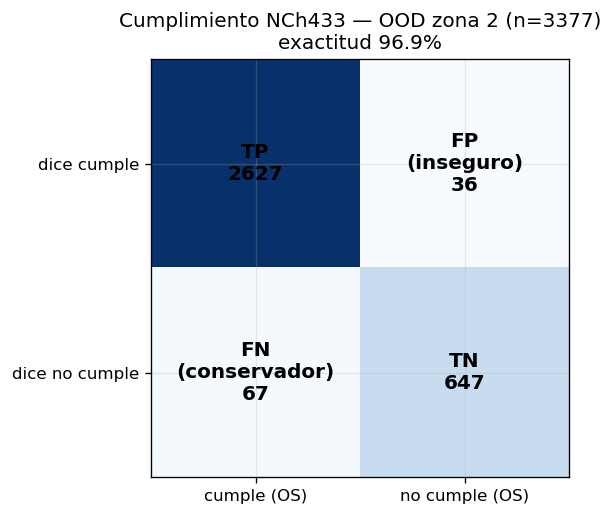

In [8]:
def fig_confusion(lang):
    t = T[lang]
    fig, ax = plt.subplots(figsize=(4.8, 4.4))
    M = np.array([[TP, FP], [FN, TN]])
    ax.imshow(M, cmap='Blues')
    labels = [['TP', f'FP\n({t["unsafe"]})'], [f'FN\n({t["conserv"]})', 'TN']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{labels[i][j]}\n{M[i,j]}', ha='center', va='center',
                    fontsize=12, fontweight='bold')
    ax.set_xticks([0,1]); ax.set_xticklabels([t['complies_os'], t['fails_os']])
    ax.set_yticks([0,1]); ax.set_yticklabels([t['pred_complies'], t['pred_fails']])
    ax.set_title(f"{t['cm_title']} (n={n})\n{t['accuracy']} {acc*100:.1f}%")
    fig.tight_layout(); return fig

for lang in IDIOMAS:
    f = fig_confusion(lang); guardar_figura(f, '01_matriz_confusion', lang)
    (plt.show() if lang == 'es' else plt.close(f))

## 5. Dónde caen los errores respecto del límite

Predicha vs real, con las líneas del límite $0{,}002$. Los **cuadrantes** muestran TP/TN
(aciertos), **FP** (rojo, inseguro: bajo el límite en predicción pero sobre el límite real) y
**FN** (naranjo, conservador). Casi todos los errores se concentran **pegados al límite**, que
es justo donde un margen de seguridad los captura.

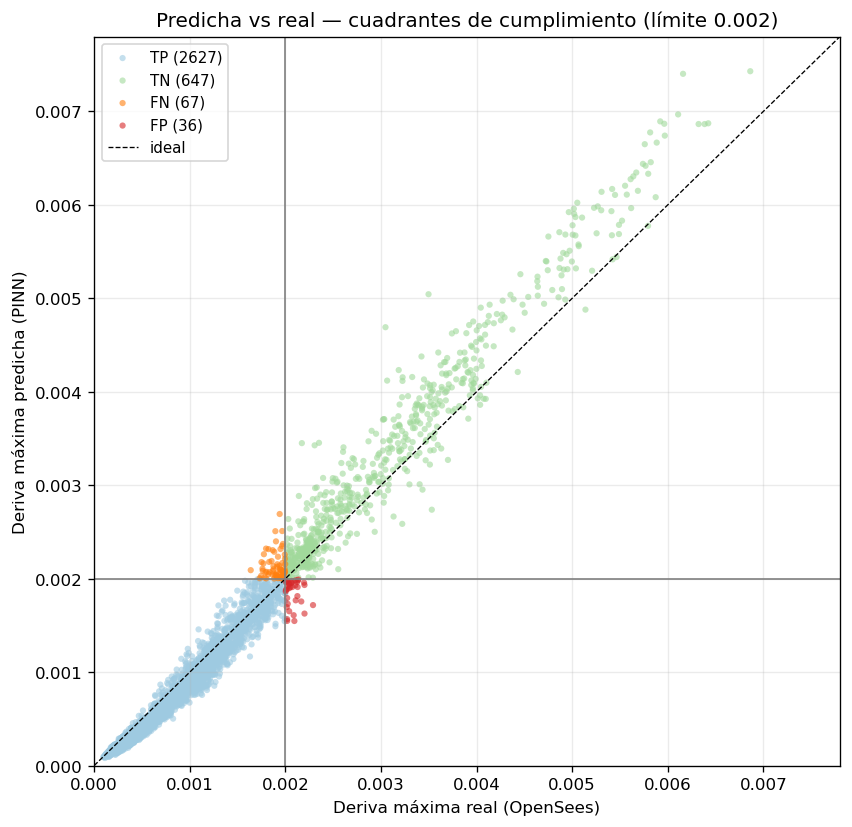

In [9]:
cls = np.where(cumple_pred & cumple_true, 'TP',
      np.where(cumple_pred & ~cumple_true, 'FP',
      np.where(~cumple_pred & cumple_true, 'FN', 'TN')))
col = {'TP':'#9ecae1', 'TN':'#a1d99b', 'FP':'#d62728', 'FN':'#ff7f0e'}
lim = max(drift_true.max(), drift_pred.max()) * 1.05

def fig_scatter(lang):
    t = T[lang]
    fig, ax = plt.subplots(figsize=(7.2, 7))
    for c in ['TP','TN','FN','FP']:
        m = cls == c
        ax.scatter(drift_true[m], drift_pred[m], s=14, alpha=0.6,
                   c=col[c], edgecolor='none', label=f'{c} ({int(m.sum())})')
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label=t['ideal'])
    ax.axvline(DRIFT_LIMIT, color='gray', lw=1); ax.axhline(DRIFT_LIMIT, color='gray', lw=1)
    ax.set_xlabel(t['sc_x']); ax.set_ylabel(t['sc_y']); ax.set_title(t['sc_title'])
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.legend(loc='upper left', fontsize=9)
    fig.tight_layout(); return fig

for lang in IDIOMAS:
    f = fig_scatter(lang); guardar_figura(f, '02_scatter_cuadrantes', lang)
    (plt.show() if lang == 'es' else plt.close(f))

## 6. La herramienta: margen de seguridad sobre el umbral de decisión

Idea: en vez de declarar *cumple* cuando la deriva predicha $\le 0{,}002$, usar un umbral de
decisión **más estricto** $\tau < 0{,}002$. Todo edificio con deriva predicha entre $\tau$ y
$0{,}002$ se marca como **"a verificar con FEM"** en vez de aprobarse. Esto **convierte
posibles FP (inseguros) en FN (conservadores)**: el metamodelo deja de aprobar casos dudosos.

Barremos $\tau$ y vemos cómo caen los FP (riesgo) a costa de más FN (casos enviados a FEM).
El **punto de operación seguro** es el $\tau$ donde FP $\to 0$.

Sin margen (tau=0.002): FP=36 inseguros, FN=67 a FEM
Punto seguro tau=0.00154: FP=0 | FN=401 | 1084 edificios (32.1%) marcados para FEM


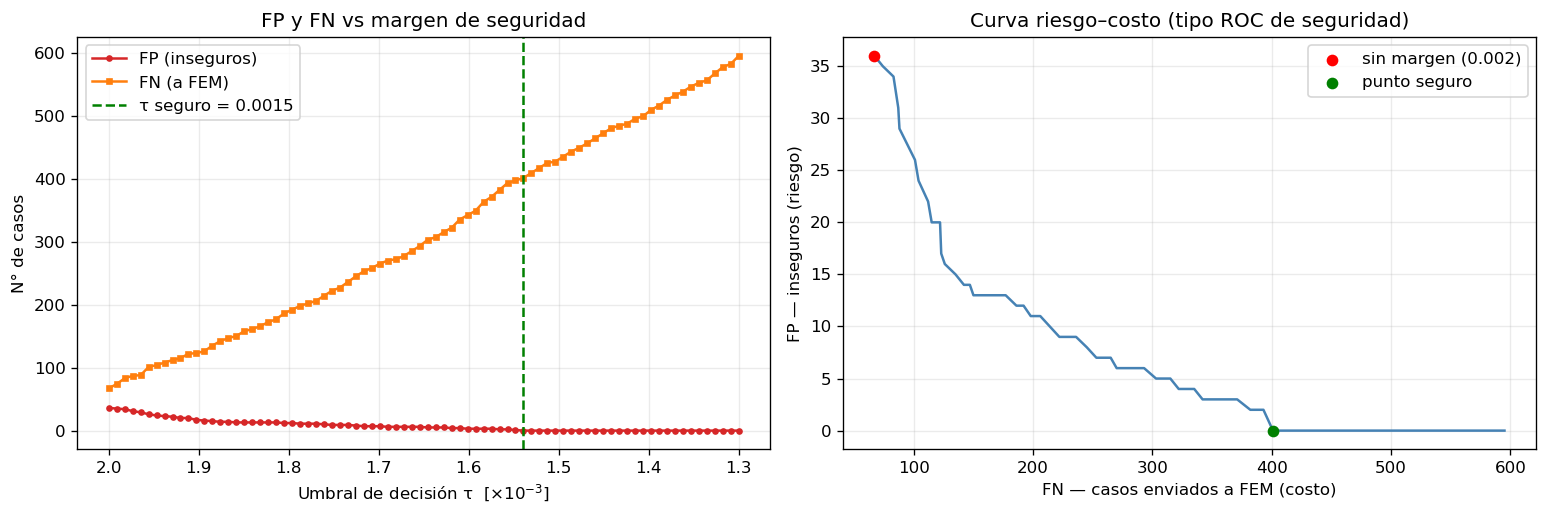


Figuras PDF guardadas en ./figuras/ :
   01_matriz_confusion_en.pdf
   01_matriz_confusion_es.pdf
   02_scatter_cuadrantes_en.pdf
   02_scatter_cuadrantes_es.pdf
   03_margen_seguridad_en.pdf
   03_margen_seguridad_es.pdf


In [10]:
taus = np.linspace(DRIFT_LIMIT, 0.0013, 80)        # de 0.002 hacia umbrales mas estrictos
FP_t, FN_t, flag_t = [], [], []
for tau in taus:
    cp = drift_pred <= tau                              # regla de decision (estricta)
    FP_t.append(int((cp & ~cumple_true).sum()))         # siguen siendo inseguros
    FN_t.append(int((~cp & cumple_true).sum()))         # conformes que ahora se mandan a FEM
    flag_t.append(int((~cp).sum()))                     # total marcados "verificar con FEM"
FP_t, FN_t, flag_t = map(np.array, (FP_t, FN_t, flag_t))

# tau seguro: el menos estricto que ya da FP = 0
seguro = taus[FP_t == 0]
tau_seg = seguro.max() if len(seguro) else taus[-1]
i_seg = int(np.argmin(np.abs(taus - tau_seg)))
print(f'Sin margen (tau=0.002): FP={FP_t[0]} inseguros, FN={FN_t[0]} a FEM')
print(f'Punto seguro tau={tau_seg:.5f}: FP={FP_t[i_seg]} | FN={FN_t[i_seg]} | '
      f'{flag_t[i_seg]} edificios ({flag_t[i_seg]/n*100:.1f}%) marcados para FEM')

def fig_margen(lang):
    t = T[lang]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
    ax[0].plot(taus*1000, FP_t, 'o-', color='#d62728', ms=3, label=t['fp_unsafe'])
    ax[0].plot(taus*1000, FN_t, 's-', color='#ff7f0e', ms=3, label=t['fn_fem'])
    ax[0].axvline(tau_seg*1000, color='green', ls='--', label=f"{t['safe_tau']} = {tau_seg:.4f}")
    ax[0].set_xlabel(t['sm_x']); ax[0].set_ylabel(t['sm_y'])
    ax[0].set_title(t['sm_title']); ax[0].legend(); ax[0].invert_xaxis()
    ax[1].plot(FN_t, FP_t, '-', color='steelblue')
    ax[1].scatter([FN_t[0]], [FP_t[0]], c='red', zorder=5, label=t['no_margin'])
    ax[1].scatter([FN_t[i_seg]], [FP_t[i_seg]], c='green', zorder=5, label=t['safe_point'])
    ax[1].set_xlabel(t['rc_x']); ax[1].set_ylabel(t['rc_y']); ax[1].set_title(t['rc_title']); ax[1].legend()
    fig.tight_layout(); return fig

for lang in IDIOMAS:
    f = fig_margen(lang); guardar_figura(f, '03_margen_seguridad', lang)
    (plt.show() if lang == 'es' else plt.close(f))

print('\nFiguras PDF guardadas en ./figuras/ :')
for fn in sorted(os.listdir(FIG_DIR)):
    print('  ', fn)

## 7. Conclusión (para el paper)

- El metamodelo predice el **veredicto de cumplimiento** de NCh433 con alta exactitud sobre un
  conjunto **fuera de distribución** (zona 2), y su error es **netamente conservador** (FN > FP):
  tiende a descartar diseños válidos antes que a aprobar diseños no conformes.
- Los pocos **falsos positivos** (inseguros) se concentran **pegados al límite** $0{,}002$, donde
  el error de predicción puede cruzar la frontera.
- Introduciendo un **margen de seguridad** sobre el umbral de decisión, los falsos positivos se
  llevan a **cero**, a costa de marcar una fracción acotada de edificios para verificación FEM.
  Esto transforma al metamodelo en un **tamiz de cumplimiento seguro**: aprueba con confianza,
  y deriva lo dudoso al análisis riguroso.
- **Implicancia de diseño:** el metamodelo no reemplaza al FEM en la certificación, pero filtra
  el espacio de diseño en milisegundos sin incurrir en riesgo, porque su operación se calibra
  explícitamente para no aprobar configuraciones no conformes.
